In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
print(f"Number of null values in total_bedrooms: {df['total_bedrooms'].isnull().sum()}")

Number of null values in total_bedrooms: 207


In [4]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [5]:
df['total_bedrooms'].isnull().sum()

np.int64(0)

In [6]:
# finding the iqr, lower bound and upper bound of the total_bedroom column
column = 'total_bedrooms'
q1 = df[column].quantile(0.25)
q3 = df[column].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Column = {column}")
print(f"Irq = {iqr:.2f}")
print(f"lower_bound = {lower_bound:.2f}")
print(f"upper_bound = {upper_bound:.2f}")

Column = total_bedrooms
Irq = 346.25
lower_bound = -222.38
upper_bound = 1162.62


In [7]:
# finding outliers in the column 
outliers = df[(df[column]<lower_bound) | (df[column]>upper_bound)]
print(f"Outliers: {len(outliers)}")

Outliers: 1306


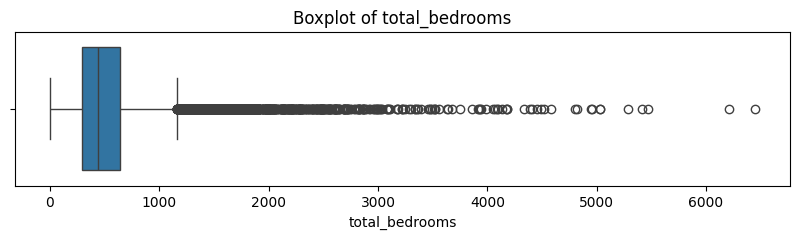

In [8]:
# visualizing the outliers using boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x = df[column])
plt.title(f"Boxplot of {column}")
plt.show()

In [9]:
# Removing the outliers from the column
cleaned_df = df[(df[column]>=lower_bound)&(df[column]<=upper_bound)]

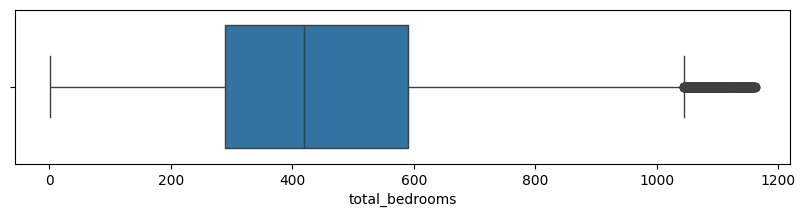

In [10]:
# visualizing the data after removing the outliers using boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x = cleaned_df[column])
plt.show()

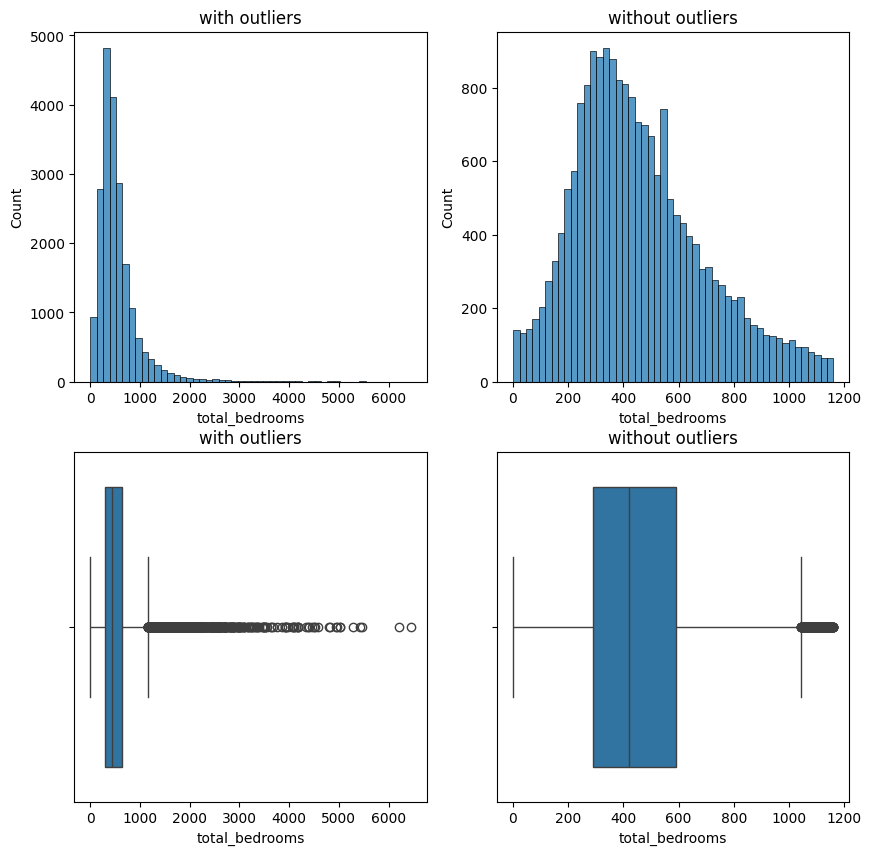

In [11]:
# comparing the data using histogram and boxplot before and after removing the outliers
fig,  ax = plt.subplots(2, 2, figsize=(10,10))
sns.histplot(df[column], bins=50, ax = ax[0,0])
sns.histplot(cleaned_df[column], bins=50, ax = ax[0,1])
sns.boxplot(x = df[column], ax = ax[1,0])
sns.boxplot(x = cleaned_df[column], ax = ax[1,1])
ax[0,0].set_title("with outliers")
ax[0,1].set_title("without outliers")
ax[1,0].set_title("with outliers")
ax[1,1].set_title("without outliers")
plt.show()

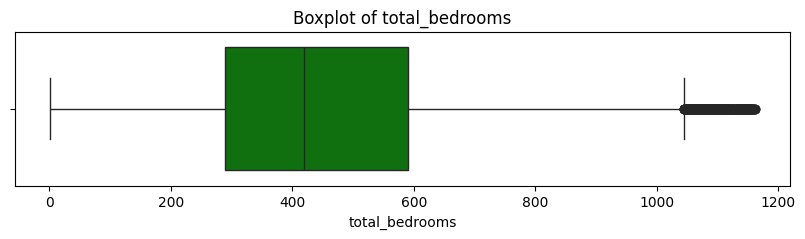

In [12]:
plt.figure(figsize=(10,2))
sns.boxplot(x = cleaned_df[column], color = 'green')
plt.title(f"Boxplot of {column}")
plt.show()